In [2]:
from config_path import add_to_sys_path
add_to_sys_path()  # Call the function to add path

import numpy as np
from sympy.physics.wigner import wigner_3j,wigner_6j
import sympy as sy
from numpy import linalg as LA
from IPython.display import Latex
import matplotlib.pyplot as plt
# %matplotlib qt

#The following three lines are only for asthetics and can be commented out if desired
import seaborn as sns
sns.set()
sns.set_palette('terrain')

from Energy_Levels import MoleculeLevels
np.set_printoptions(precision=5, suppress=True)

This notebook computes the energy levels for M-X molecules, M=metal, X=Ligand

The heart of the code is the MoleculeLevels class. This class is initialized using a class method:

In [3]:
X0 = MoleculeLevels.initialize_state(
    molecule_name = 'RaF',
    elec_state = 'X',
    vib_state = 0,
    N_list = [0,1,2],
    fermion_or_boson = 'boson', # aka is the total F integer or half-integer?
    M_sublevels = 'all',
    I_nuclei = [0,1/2],
    round=8
)

No projection values of J provided, using minimal projection 0.5 as default


Complete info about initialize_state can be obtained with help()

In [4]:
help(MoleculeLevels.initialize_state)

Help on method initialize_state in module Energy_Levels:

initialize_state(molecule_name, elec_state, vib_state, N_list, fermion_or_boson='boson', params=None, S_electron=0.5, M_sublevels='all', M_list=[], I_nuclei=[0, 0.5], isotope=None, P_values=[], round=6, trap=False, theta_num=None) class method of Energy_Levels.MoleculeLevels
    This is a method to initialize a molecule state object.

    Args:
    molecule_name: string, name of molecule, e.g. 'YbOH'
    elec_state: string, name of state, e.g. 'X' or 'A'
    vib_state: string or integer, vibrational level, e.g. 0,1,... for diatomics or '000', '010', for triatomics
    N_list: list of values of rotational quantum number N to include (e.g. [N for N in N_values])

    Keyword Args:
    fermion_or_boson: string, 'fermion' or 'boson' (default), determines spin statistics (i.e. F=half-integer or integer)
    params: dictionary of molecular parameters, default None imports based on molecule and state
    S_electron: electronic spin, de

The instance X0 of the class MoleculeLevels carries information about the RaX ground state. We can check out its attributes and see what they return. We see that the effective Hamiltonian parameters are available.

In [5]:
X0.__dict__

{'molecule': 'RaF',
 'spin_statistics': 'boson',
 'electronic_state': 'X',
 'vibrational_state': 0,
 'vibronic_state': 'X0',
 'parameters': {'mu_B': 1.399624494,
  'g_S': 2.0023,
  'g_L': 1,
  '2_e0c': 75346062800.0,
  'mu_N': 0.000762259323,
  'c': 19,
  'Be': 5755.56,
  'Gamma_SR': 175.38,
  'bF': 96.3,
  'muE': 1.96834092,
  'D': 0.004197094412},
 'N_range': [0, 1, 2],
 'M_values': 'all',
 'round': 8,
 'e_spin': 0.5,
 'I_spins': [0, 0.5],
 'M_range': [],
 'P_values': [0.5],
 'trap': False,
 'theta_num': None,
 'metadata': {'isotope': None},
 'iso_state': '174X000',
 'library': <molecule_library_class.Molecule_Library at 0x15b3cfe00>,
 'matrix_elements': {'N^2': functools.partial(<function Rot_bBJ at 0x14ba0cea0>, I=0.5),
  'N.S': functools.partial(<function SR_bBJ at 0x14ba0cf40>, I=0.5),
  'l-doubling': functools.partial(<function lD_bBJ at 0x14ba0d940>, I=0.5),
  'l doubling p': functools.partial(<function p_lD_bBJ at 0x14ba0d800>, I=0.5),
  'l doubling q': functools.partial(<func

The Hamiltonian itself is stored in two forms: H_function and H_symbolic.

H_function(E,B) returns the numeric Hamiltonian at Ez = E and Bz = B. 

H_symbolic returns a Hamiltonian where Ez and Bz remain symbols, and is mostly for visualization and debugging

In [6]:
X0.H_function(0,1e-3)

array([[  -72.225  ,     0.     ,     0.0014 , ...,     0.     ,
            0.     ,     0.     ],
       [    0.     ,    24.0736 ,     0.     , ...,     0.     ,
            0.     ,     0.     ],
       [    0.0014 ,     0.     ,    24.075  , ...,     0.     ,
            0.     ,     0.     ],
       ...,
       [    0.     ,     0.     ,     0.     , ..., 34731.75961,
            0.     ,     0.     ],
       [    0.     ,     0.     ,     0.     , ...,     0.     ,
        34731.76008,     0.     ],
       [    0.     ,     0.     ,     0.     , ...,     0.     ,
            0.     , 34731.76054]])

The Hamiltonian is expressed in some basis, depending on the state of interest. Each basis vector is labeled by a series of quantum numbers, given by the object q_str. Note this does not include quantum numbers that are the same for all of our states, such as S or I.

q_numbers is a dictionary containing the quantum numbers describing each basis vector. For RaF X, the basis vector is $|\Lambda;N,S,J,I,F,M\rangle$. Each value in q_numbers corresponds to a list the values taken on by the quantum number in the key. So the ith basis vector is characterized by the ith index of each entry in q_numbers. q_str is just the keys of q_numbers in a list.

So for example, q_numbers['J'][3] is the 'J' value for the 3rd index basis vector.

In [7]:
print(X0.q_str)
for q in X0.q_str:
    print(f'{q} =',X0.q_numbers[q])

print('')
i=5
print('Basis vector',i)
for q, q_value in X0.q_numbers.items():
    print(q,'=',q_value[i])

['K', 'N', 'J', 'F', 'M']
K = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
N = [0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
J = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]
F = [0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
M = [0.0, -1.0, 0.0, 1.0, 0.0, -1.0, 0.0, 1.0, -1.0, 0.0, 1.0, -2.0, -1.0, 0.0, 1.0, 2.0, -1.0, 0.0, 1.0, -2.0, -1.0, 0.0, 1.0, 2.0, -2.0, -1.0, 0.0, 1.0, 2.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]

Basis vector 5
K = 0
N = 1.0
J = 0.5
F = 1.0
M = -1.0


We can visualize slices of the Hamiltonian with regular indexing

In [8]:
print(X0.H_function(0,0)[:6,:6])

[[  -72.225       0.          0.          0.          0.          0.     ]
 [    0.         24.075       0.          0.          0.          0.     ]
 [    0.          0.         24.075       0.          0.          0.     ]
 [    0.          0.          0.         24.075       0.          0.     ]
 [    0.          0.          0.          0.      11353.46488     0.     ]
 [    0.          0.          0.          0.          0.      11329.80932]]


In [9]:
sy.N(X0.H_symbolic[:6,:6],2)

Matrix([
[  -72.0,              0,  1.4*B_z,              0,        0,                 0],
[      0, 24.0 - 1.4*B_z,        0,              0,        0,         -0.66*E_z],
[1.4*B_z,              0,     24.0,              0, 0.66*E_z,                 0],
[      0,              0,        0, 1.4*B_z + 24.0,        0,                 0],
[      0,              0, 0.66*E_z,              0,   1.1e+4,                 0],
[      0,      -0.66*E_z,        0,              0,        0, 0.47*B_z + 1.1e+4]])

evals0 and evecs0 contain the eigenvalues and eigenvectors associated with the most recent diagonalization.
To diagonalize the matrix at a particular value of $E$ and $B$, use the eigensystem method. $E$ is the first argument, $B$ is the second.

The resulting eigenvectors and eigenvalues are written to the attributes evecs0 and evals0.

The order keyword arg will order the output eigenvalues from low to high, default is True. The method keyword arg controls the backend used for diagonalization, default is numpy LA.eig().

Note: If you have M_values not 'none', you will need a small B field (1e-8 or so) to remove the M degeneracy in the diagonalization. 

In [10]:
evals, evecs = X0.eigensystem(0,1e-6,order=True,method='numpy')

Once the instance has eigenvalues and eigenvectors, you can use the write_state() method to visualize a given element in the eigenbasis. 

Note: write_state() looks at the current values of evecs0 and evals0

In [11]:
for i in range(4):
    X0.write_state(i)

E = -72.225 MHz

 1.0 |K=0,N=0.0,J=0.5,F=0.0,M=0.0> 

 -1e-08 |K=0,N=0.0,J=0.5,F=1.0,M=0.0> 

E = 24.07441333 MHz

 0.99999999 |K=0,N=0.0,J=0.5,F=1.0,M=-1.0> 

 -1e-08 |K=0,N=0.0,J=0.5,F=1.0,M=1.0> 

 -0.00013069 |K=0,N=2.0,J=1.5,F=1.0,M=-1.0> 

E = 24.07441473 MHz

 -1e-08 |K=0,N=0.0,J=0.5,F=0.0,M=0.0> 

 -0.99999999 |K=0,N=0.0,J=0.5,F=1.0,M=0.0> 

 0.00013069 |K=0,N=2.0,J=1.5,F=1.0,M=0.0> 

E = 24.07441613 MHz

 1e-08 |K=0,N=0.0,J=0.5,F=1.0,M=-1.0> 

 0.99999999 |K=0,N=0.0,J=0.5,F=1.0,M=1.0> 

 -0.00013069 |K=0,N=2.0,J=1.5,F=1.0,M=1.0> 



For pretty fancy printing, you can use the gen_state_str method.\
If label_q = None, the default is to use all q numbers in the basis. If basis is None, the default is to use the existing basis. If basis is set to 'a' or 'decoupled', the quantum numbers for those bases will be used instead. \
Thresh sets the cutoff for coefficients to be included.

In [12]:
help(X0.select_q)

Help on method select_q in module Energy_Levels:

select_q(q_dict, evecs=None, parity=None) method of Energy_Levels.MoleculeLevels instance



In [13]:
X0.eigensystem(200,1e-6);
idx = X0.select_q({'M':0})
print(idx)

[ 0  1  6  7 10 15 20 23 28 35]


In [14]:
Latex(X0.gen_state_str(idx[0],label_q=['K','N','J','F','M'],basis=None,thresh=0.01,show_coeff=True,round=None))

<IPython.core.display.Latex object>

If M_values is not 'none', we can also generate Stark and Zeeman shift plots

In [15]:
Bz = np.linspace(1e-8,100,1000)
Ez = np.linspace(0.0,500,1000)

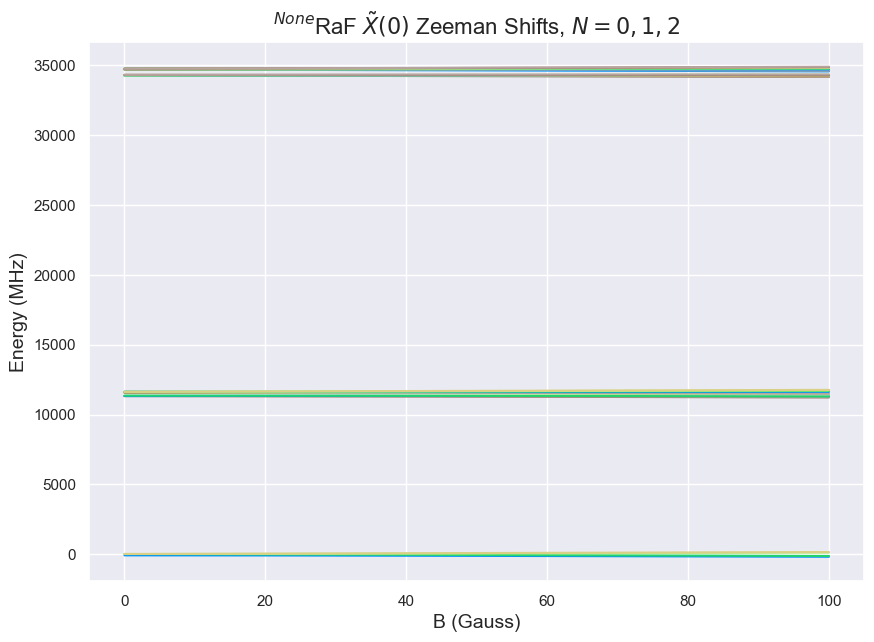

In [16]:
X0.ZeemanMap(Bz,0,plot=True)

The field shifts are stored as attributes. This allows us to compute the derivative of the Zeeman shifts, which tells us the magnetization of the levels.

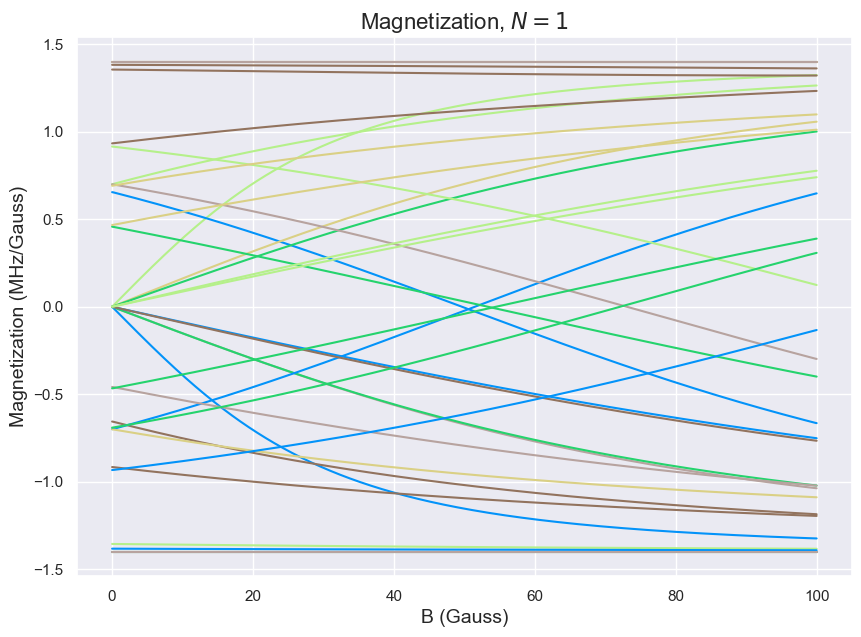

In [17]:
dB = Bz[1] - Bz[0]
plt.figure(figsize=(10,7))
for (i,trace) in enumerate(X0.evals_B.T):
    plt.plot(Bz,np.gradient(trace,dB))
plt.xlabel('B (Gauss)',fontsize=14)
plt.ylabel('Magnetization (MHz/Gauss)',fontsize=14)
plt.title(r'Magnetization, $N=1$',fontsize=16);

We can either plot directly with the StarkMap/ZeemanMap function, or we can use plot_evals_EB() to plot with additional options.

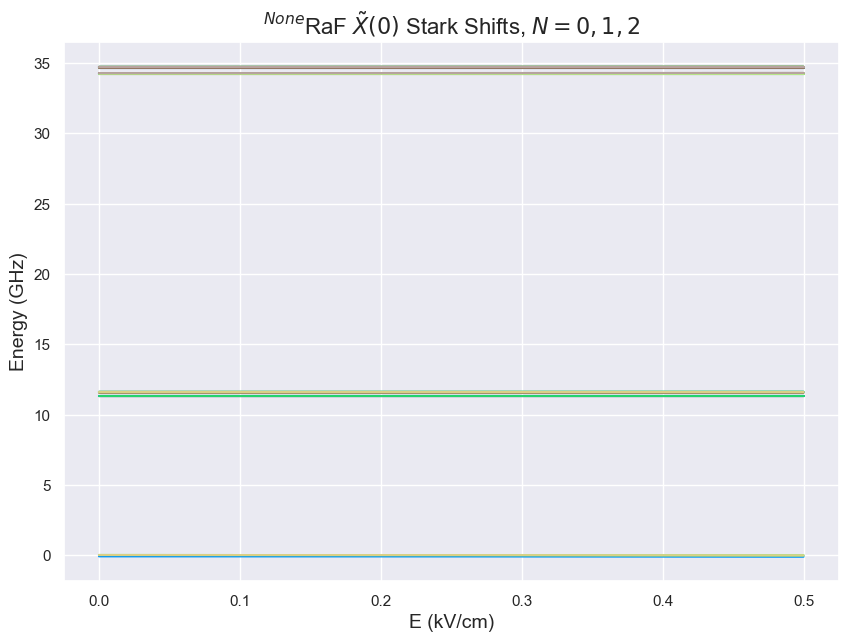

In [18]:
X0.StarkMap(Ez,1e-5,plot=False)
X0.plot_evals_EB('E',kV_kG=True,GHz=True)

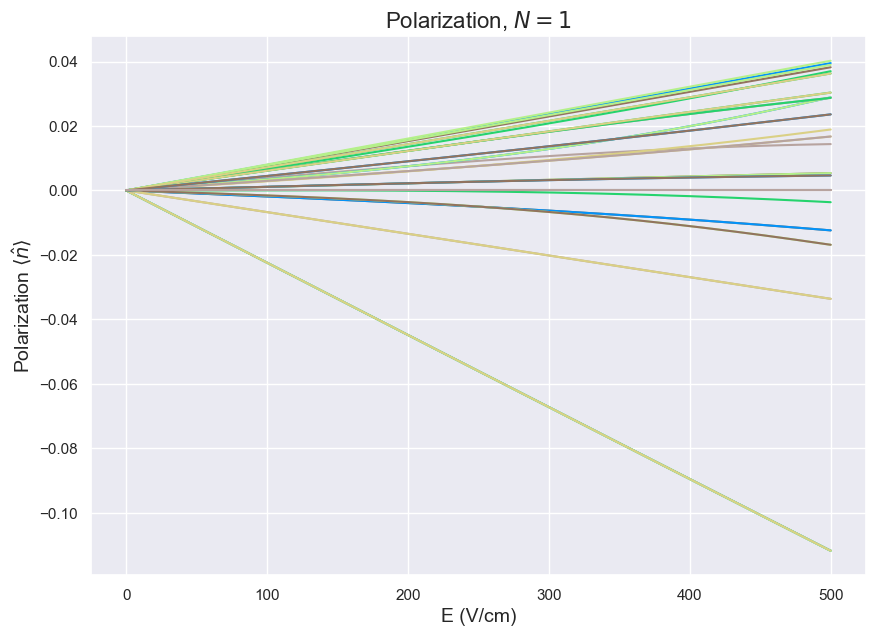

In [19]:
dE = Ez[1] - Ez[0]
plt.figure(figsize=(10,7))
for (i,trace) in enumerate(X0.evals_E.T):
    grad = np.gradient(trace,dE)
    plt.plot(Ez,grad)
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel(r'Polarization $\langle \hat{n} \rangle$',fontsize=14)
plt.title(r'Polarization, $N=1$',fontsize=16);

We can display a plot of the energy levels at arbitray field. (The code does not handle parity labeling well, so I am leaving out L for zero field.)\
The first and second argument are the E and B field values. The third argument is the pattern forming quantum number that sets how often the levels are labeled.

In [20]:
help(X0.display_levels)

Help on method display_levels in module Energy_Levels:

display_levels(Ez, Bz, pattern_q, idx=None, label=True, label_off=0.03, parity=False, pretty=True, thickness=1.5, label_q=None, width=0.75, ket_size=10, label_size=14, figsize=(10, 10), ylim=None, deltaE_label=3000, alt_label=False) method of Energy_Levels.MoleculeLevels instance



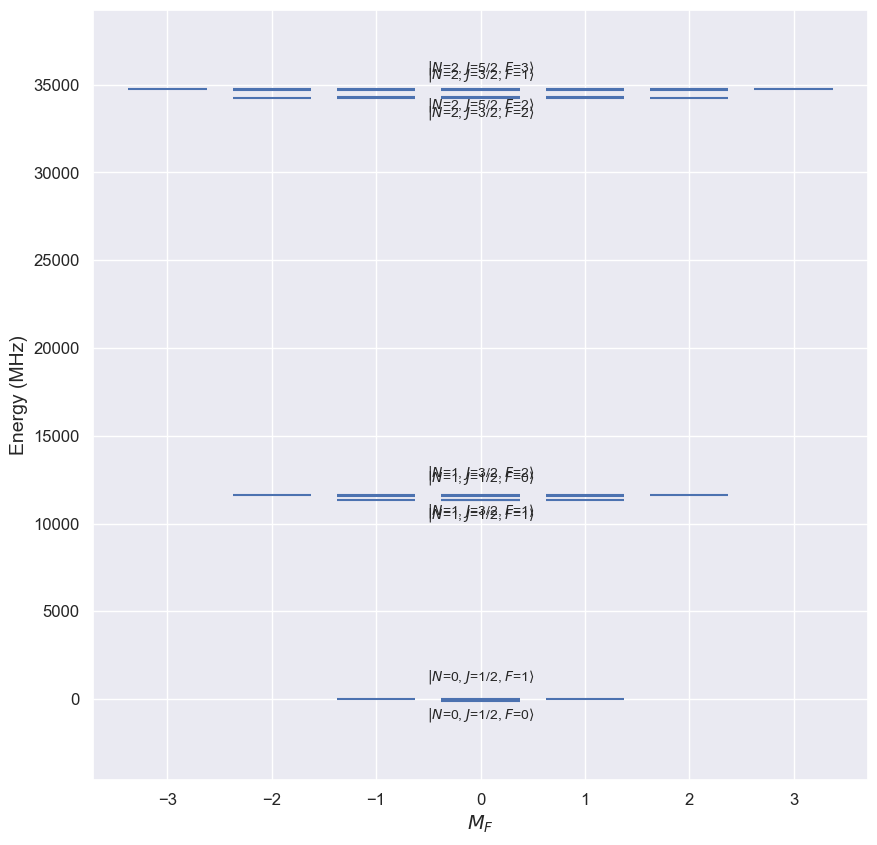

In [21]:
X0.display_levels(0,1e-8,'F',label_q=[q for q in X0.q_str if q!='K'],alt_label=True);

Additionally we can look at g-factors and dipole moments at a given E, B field

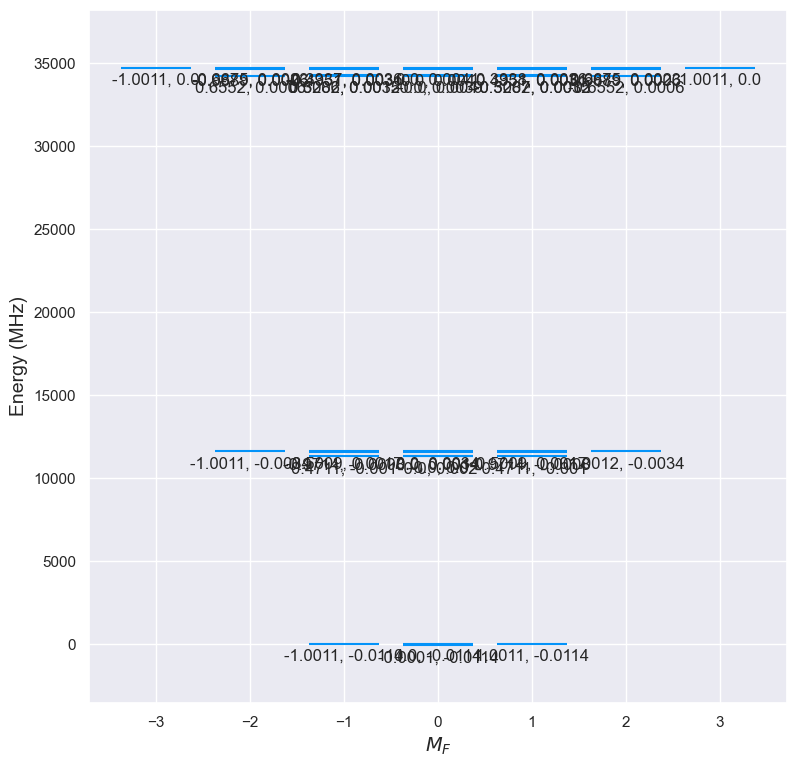

In [22]:
X0.display_g_D_eff(100,1e-3,Estep=1e-1,Bstep=1e-3,round=4);

We can also look at PT violating shifts. Here, we consider the EDM shifts as a function of E field.

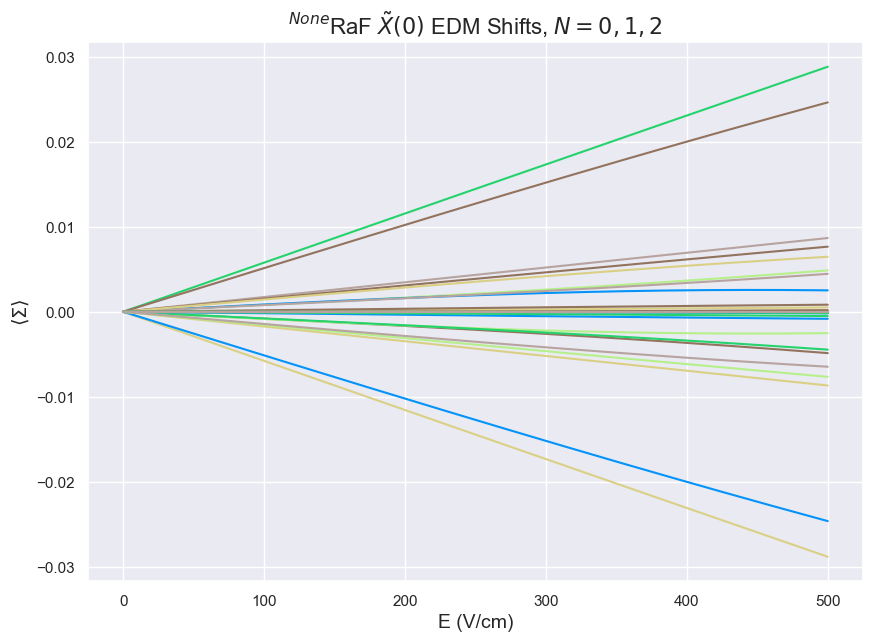

In [23]:
X0.PTV_Map('EDM',E_or_B='E',plot=True)

The values are stored in the attrbiute PTV_E or PTV_B, depending on what x-axis was used. To obtain the PTV shift for a single level as a function of field, look at the transpose of PTV_E.

You can also display the PTV shifts for all levels in a given field configuration. Once again the first argument is E and the second is B

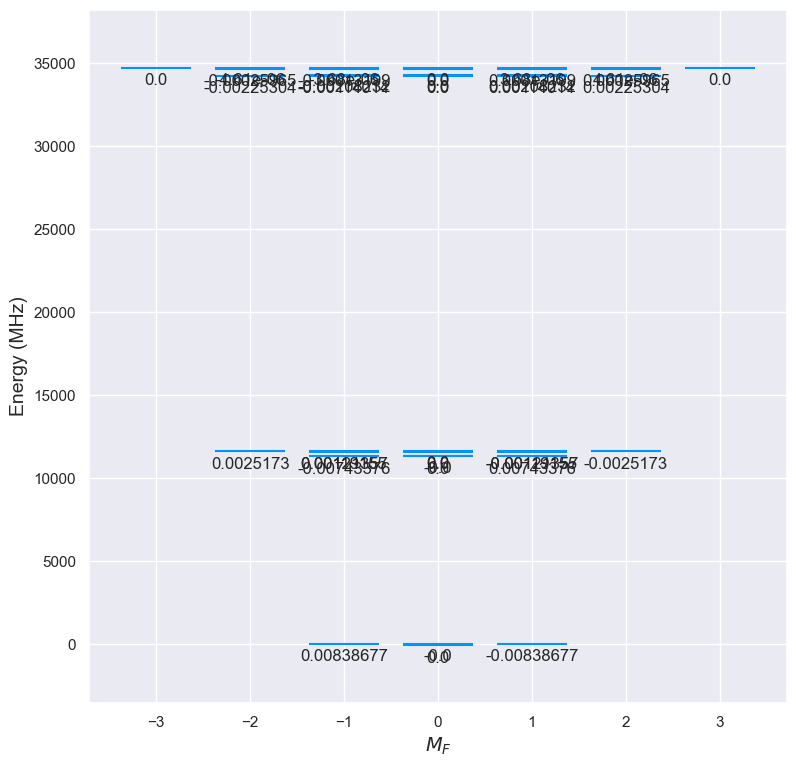

In [24]:
X0.display_PTV(145,1e-6,'EDM')

You can also look at g_factors as a function of E or B field. Note these functions require StarkMap and ZeemanMap to be run previously. If step is too small, the data will be noisy.

In [25]:
X0.g_eff_Map('E',step=1e-3);

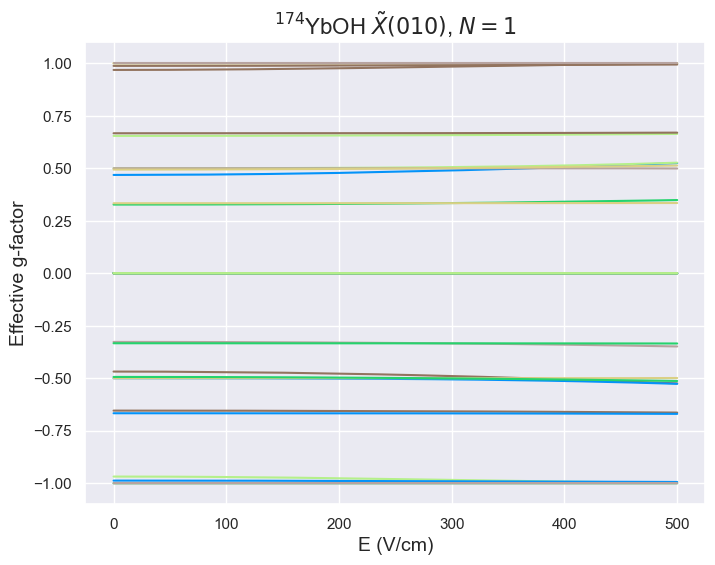

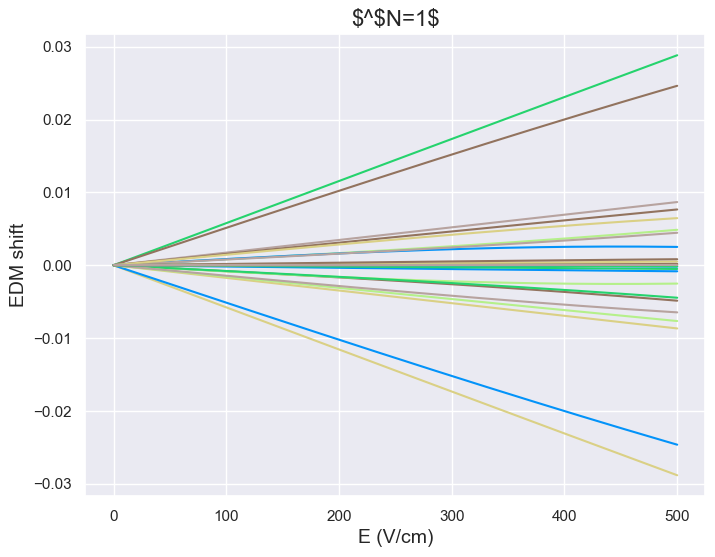

In [26]:
j = range(len(X0.evals0))
plt.figure(figsize=(8,6))
for i in j:#range(len(X010_174.g_eff_E.T)):
    plt.plot(Ez,X0.g_eff_E.T[i])
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel('Effective g-factor',fontsize=14)
plt.title(r'$^{174}$YbOH $\tilde{X}(010)$, $N=1$',fontsize=16);
plt.figure(figsize=(8,6))
for i in j:#range(len(X010_174.PTV_E.T)):
    plt.plot(Ez,X0.PTV_E.T[i])
plt.xlabel('E (V/cm)',fontsize=14)
plt.ylabel('EDM shift',fontsize=14)
plt.title(r'$^$N=1$',fontsize=16);